In [29]:
!pip install prophet pandas matplotlib seaborn plotly -q
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import numpy as np

In [30]:
#HKU Sustainability Club (Eco Bags Demand Data)

dates = pd.date_range(start='2025-01-05', periods=52, freq='W-SUN')   # Weekly data for 1 year

# Previous weekly demand (units distributed)
weekly_demand = [
    120, 135, 110, 150, 160, 140, 155, 170,
    130, 145, 125, 165, 175, 155, 165, 180,
    140, 150, 135, 170, 185, 160, 175, 190,
    145, 160, 140, 180, 195, 170, 185, 200,
    155, 165, 150, 190, 205, 175, 195, 210,
    160, 175, 155, 200, 215, 185, 200, 220,
    170, 180, 165, 210
]

# Create clean DataFrame with meaningful column names
demand_data = pd.DataFrame({
    'week_start_date': dates,
    'eco_bags_distributed': weekly_demand
})

print("✅ Dataset Created Successfully!")
print(f"Total weeks of data: {len(demand_data)}")
print("\nFirst 5 weeks:")
print(demand_data.head())

✅ Dataset Created Successfully!
Total weeks of data: 52

First 5 weeks:
  week_start_date  eco_bags_distributed
0      2025-01-05                   120
1      2025-01-12                   135
2      2025-01-19                   110
3      2025-01-26                   150
4      2025-02-02                   160


In [31]:
prophet_data = demand_data.rename(columns={
    'week_start_date': 'ds',
    'eco_bags_distributed': 'y'
})

print("Data prepared for Prophet model")
print(prophet_data.head())

Data prepared for Prophet model
          ds    y
0 2025-01-05  120
1 2025-01-12  135
2 2025-01-19  110
3 2025-01-26  150
4 2025-02-02  160


In [32]:
#Model Tarining
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(prophet_data)

In [33]:
# Forecast next 12 weeks
future_periods = 12
future_dates = model.make_future_dataframe(periods=future_periods, freq='W')

forecast = model.predict(future_dates)

print(f"Forecast generated for next {future_periods} weeks!")
print("\nForecast for next 4 weeks:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4))

Forecast generated for next 12 weeks!

Forecast for next 4 weeks:
           ds        yhat  yhat_lower  yhat_upper
60 2026-03-01  251.507613  232.852686  267.696406
61 2026-03-08  244.130992  225.837092  260.902640
62 2026-03-15  247.181737  228.503294  266.224180
63 2026-03-22  259.027584  240.301266  277.851793


<Figure size 1200x600 with 0 Axes>

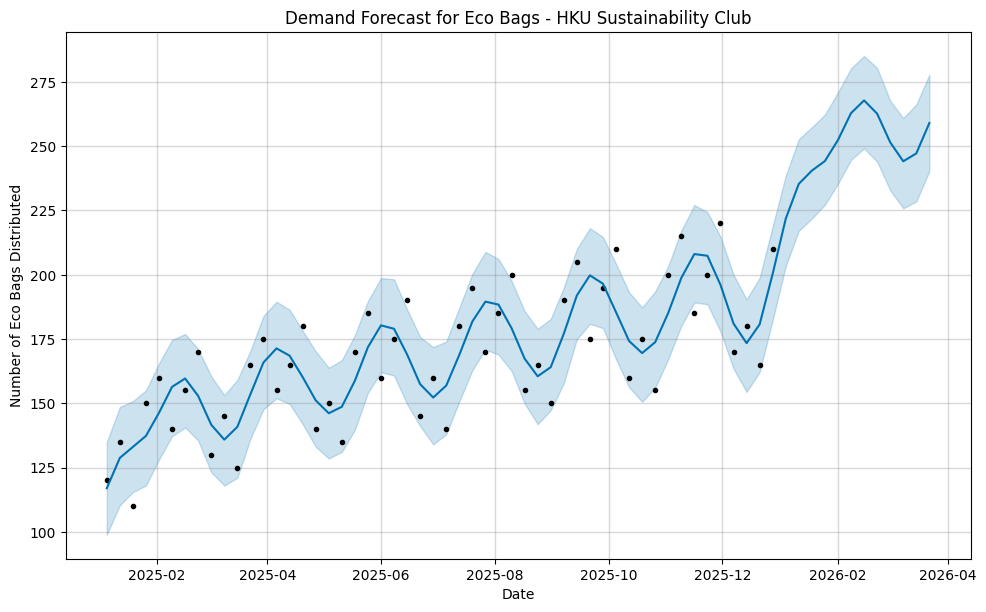

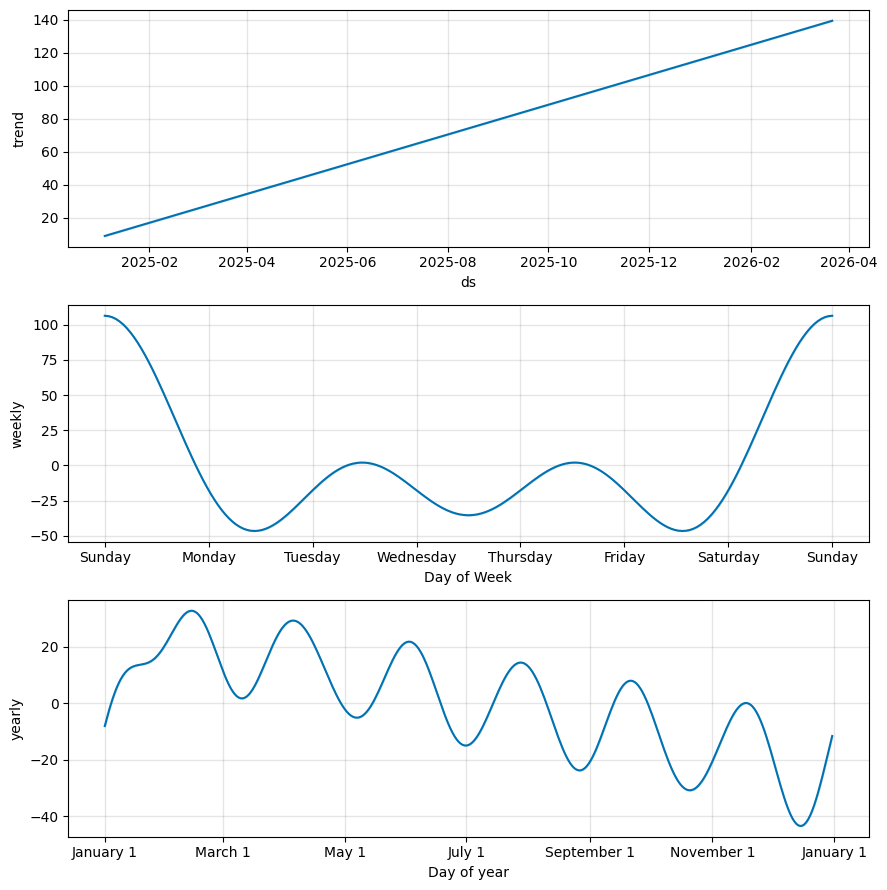

In [34]:
# Plotting the forecast
plt.figure(figsize=(12, 6))
model.plot(forecast)
plt.title("Demand Forecast for Eco Bags - HKU Sustainability Club")
plt.xlabel("Date")
plt.ylabel("Number of Eco Bags Distributed")
plt.grid(True, alpha=0.3)
plt.show()

# Trend + Seasonality breakdown
model.plot_components(forecast)
plt.show()

In [35]:
#INVENTORY OPTIMIZATION

# Assumptions I made for HKU Sustainability Club
annual_demand = demand_data['eco_bags_distributed'].sum()  # Total from previous Weekly data
holding_cost_per_unit = 8      # HKD per bag per year (storage cost)
ordering_cost_per_order = 120   # HKD per order (transport + handling from supplier)
lead_time_days = 7              # How many days it takes for new stock to arrive

print(f"Annual Demand (Eco Bags): {annual_demand:.0f} units")
print(f"Daily Average Demand: {annual_demand/365:.1f} units/day")

Annual Demand (Eco Bags): 8740 units
Daily Average Demand: 23.9 units/day


In [36]:
# Economic Order Quantity (EOQ) - Classic formula
eoq = np.sqrt((2 * annual_demand * ordering_cost_per_order) / holding_cost_per_unit)

# Average daily demand
avg_daily_demand = annual_demand / 365

# Reorder Point (when to place new order)
reorder_point = avg_daily_demand * (lead_time_days / 7)   # convert weeks to days roughly

# Safety Stock (buffer for uncertainty)
# Using simple rule: 1.65 * standard deviation of weekly demand * sqrt(lead time in weeks)
weekly_std = demand_data['eco_bags_distributed'].std()
safety_stock = 1.65 * weekly_std * np.sqrt(lead_time_days / 7)

# Recommended Order Quantity = EOQ rounded
recommended_order_qty = round(eoq)

print("\n=== INVENTORY RECOMMENDATIONS ===")
print(f"Economic Order Quantity (EOQ)     : {recommended_order_qty} Eco Bags per order")
print(f"Reorder Point                     : {reorder_point:.1f} Eco Bags")
print(f"Safety Stock                      : {safety_stock:.1f} Eco Bags")
print(f"Total Recommended Stock Level     : {reorder_point + safety_stock:.1f} Eco Bags")


=== INVENTORY RECOMMENDATIONS ===
Economic Order Quantity (EOQ)     : 512 Eco Bags per order
Reorder Point                     : 23.9 Eco Bags
Safety Stock                      : 42.2 Eco Bags
Total Recommended Stock Level     : 66.1 Eco Bags



📊 INVENTORY OPTIMIZATION SUMMARY
                     Metric      Value                                Explanation
              Annual Demand 8740 units             Total eco bags needed per year
       EOQ (Order Quantity)  512 units     Best order size to minimize total cost
              Reorder Point 23.9 units When to place new order (during lead time)
               Safety Stock 42.2 units    Buffer stock for unexpected high demand
Recommended Max Stock Level 66.1 units             Target stock level to maintain


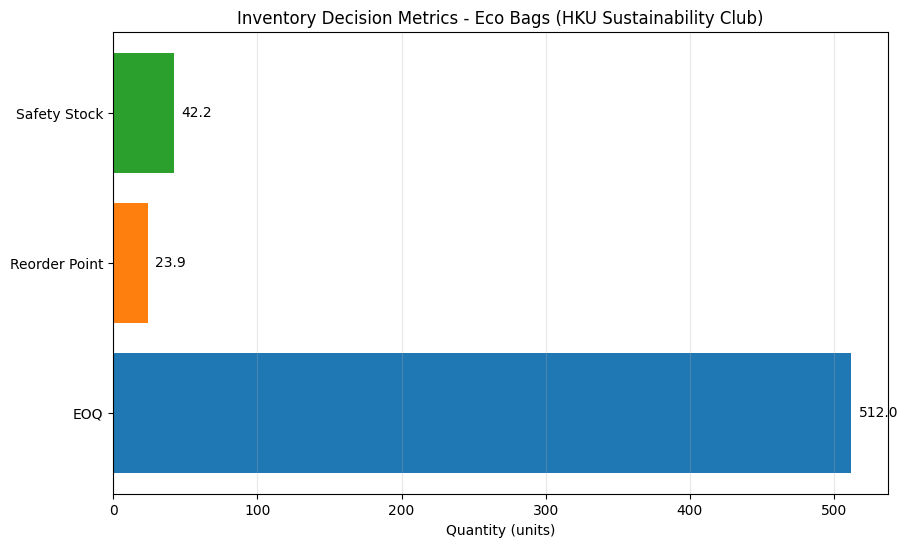

In [37]:
#Summary table
inventory_summary = pd.DataFrame({
    'Metric': ['Annual Demand', 'EOQ (Order Quantity)', 'Reorder Point',
               'Safety Stock', 'Recommended Max Stock Level'],
    'Value': [f"{annual_demand:.0f} units",
              f"{recommended_order_qty} units",
              f"{reorder_point:.1f} units",
              f"{safety_stock:.1f} units",
              f"{reorder_point + safety_stock:.1f} units"],
    'Explanation': [
        "Total eco bags needed per year",
        "Best order size to minimize total cost",
        "When to place new order (during lead time)",
        "Buffer stock for unexpected high demand",
        "Target stock level to maintain"
    ]
})

print("\n📊 INVENTORY OPTIMIZATION SUMMARY")
print(inventory_summary.to_string(index=False))

# Simple bar chart for visualization
plt.figure(figsize=(10, 6))
metrics = ['EOQ', 'Reorder Point', 'Safety Stock']
values = [recommended_order_qty, reorder_point, safety_stock]

plt.barh(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Inventory Decision Metrics - Eco Bags (HKU Sustainability Club)')
plt.xlabel('Quantity (units)')
for i, v in enumerate(values):
    plt.text(v + 5, i, f"{v:.1f}", va='center')
plt.grid(axis='x', alpha=0.3)
plt.show()